---
Author: The Tuan Trinh \
Date: 2026-05-22
---

In [1]:
import os
import platform
print("=" * 100)
print("OS Name:", os.name)
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Platform:", platform.platform())

print("\nEnvironment Variables (sample):")
for key, value in list(os.environ.items())[:15]:
    print(f"{key} = {value}")

OS Name: posix
System: Linux
Release: 4.18.0-348.12.2.el8_5.x86_64
Machine: x86_64
Processor: x86_64
Platform: Linux-4.18.0-348.12.2.el8_5.x86_64-x86_64-with-glibc2.28

Environment Variables (sample):
CONDA_SHLVL = 2
LD_LIBRARY_PATH = /usr/local/cuda/lib64:/usr/local/cuda/lib64:
CONDA_EXE = /work/tuan.tt19010226/miniconda/bin/conda
SSH_CONNECTION = 10.4.98.68 64873 10.20.8.11 22
CONDA_PREFIX = /work/tuan.tt19010226/conda/envs/RadarLM
XDG_SESSION_ID = 64511
USER = tuan.tt19010226
PWD = /home/tuan.tt19010226
HOME = /home/tuan.tt19010226
CONDA_PYTHON_EXE = /work/tuan.tt19010226/miniconda/bin/python
SSH_CLIENT = 10.4.98.68 64873 22
MESA_LOADER_DRIVER_OVERRIDE = llvmpipeexport
CONDA_PROMPT_MODIFIER = (RadarLM) 
VSCODE_CLI_REQUIRE_TOKEN = b7ebbf12-935b-4329-b0c7-398a25100c8f
SHELL = /bin/bash


In [2]:
platform.python_version()

'3.10.19'

## Lab4 - Intensity Transformations


Because I do not have grayscale image source, I manually cropped as the RGB image from book and converted them to grayscale.

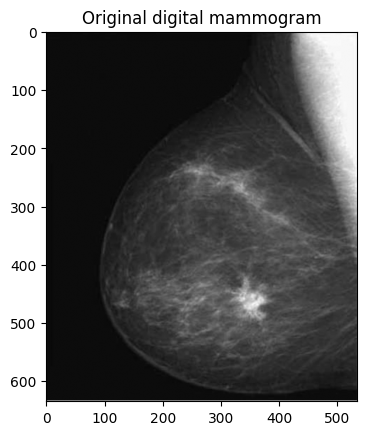

In [3]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt
img_path = "/work/tuan.tt19010226/CV-Radar-HPE/mammogram.png"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.title("Original digital mammogram")
plt.show()

### Image Negatives

The negative of an image with intensity levels in the range $[0, L-1]$ is obtained by using the negative transformation: $$s = L- 1- r$$

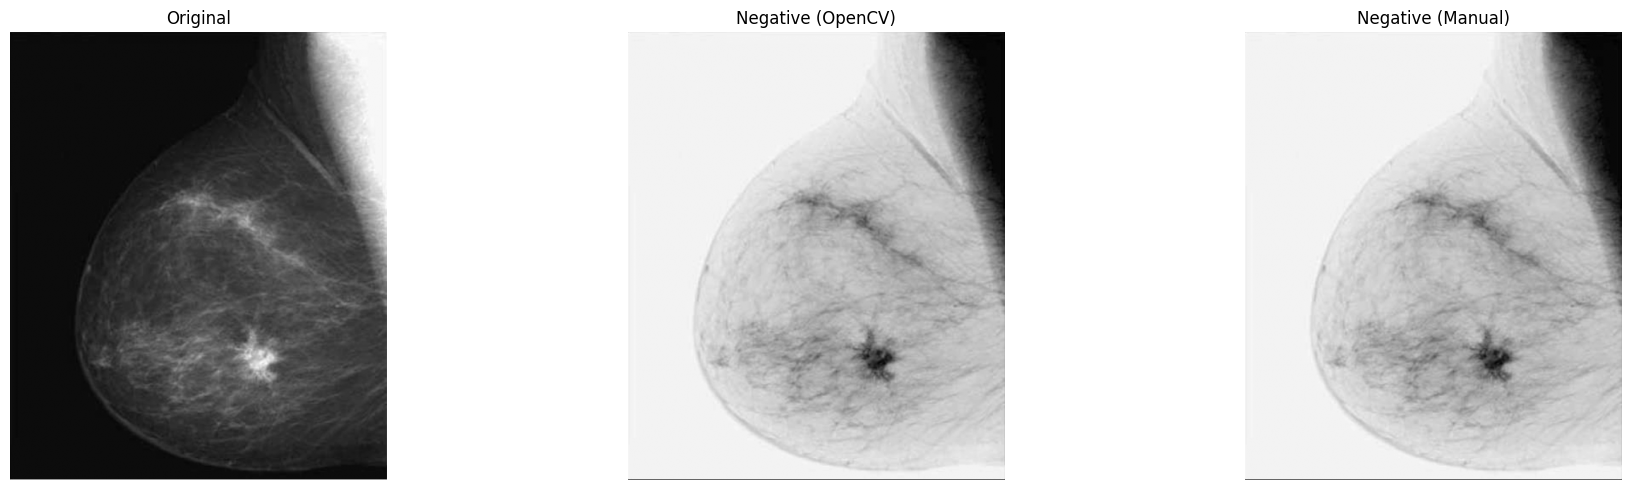

In [4]:
negative_cv = 255 - gray

pil_img = Image.fromarray(gray)
W, H = pil_img.size
negative_manual = Image.new("L", (W, H))
for y in range(H):
    for x in range(W):
        r = pil_img.getpixel((x, y))
        s = 255 - r
        negative_manual.putpixel((x, y), s)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].imshow(gray, cmap='gray')
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(negative_cv, cmap='gray')
ax[1].set_title("Negative (OpenCV)")
ax[1].axis("off")
ax[2].imshow(negative_manual, cmap='gray')
ax[2].set_title("Negative (Manual)")
ax[2].axis("off")
plt.tight_layout()
plt.show()

### Log Transformations

The general form of the log transformation is: $$s = clog(1 + r)$$ where  c is a constant, and it is assumed that 
r ≥ 0

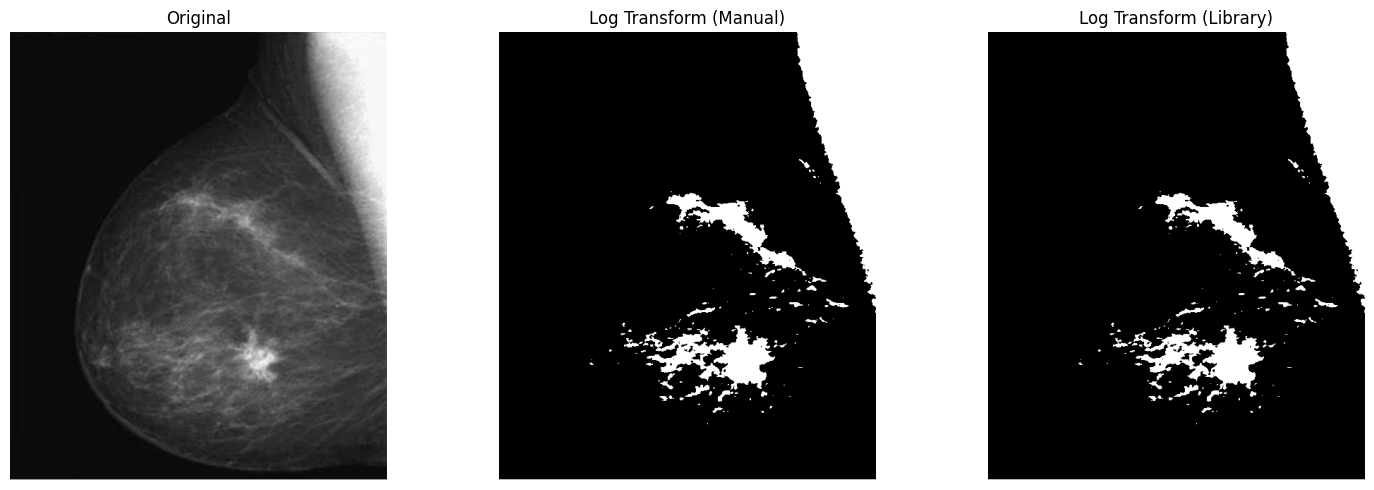

In [5]:
import numpy as np
c = 1
log_lib = c * np.log(1 + gray.astype(np.float32))
log_lib = np.array(log_lib, dtype=np.uint8)

H, W = gray.shape
log_manual = np.zeros((H, W), dtype=np.uint8)

for y in range(H):
    for x in range(W):
        r = gray[y, x]
        s = c * np.log(1 + r)
        log_manual[y, x] = int(s)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(gray, cmap='gray')
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(log_manual, cmap='gray')
ax[1].set_title("Log Transform (Manual)")
ax[1].axis("off")
ax[2].imshow(log_lib, cmap='gray')
ax[2].set_title("Log Transform (Library)")
ax[2].axis("off")
plt.tight_layout()
plt.show()

### Power-Law (Gamma) Transformations

Power-law transformations have the basic form: $$s = cr^\gamma$$ where $c$ and $\gamma$ are positive constants

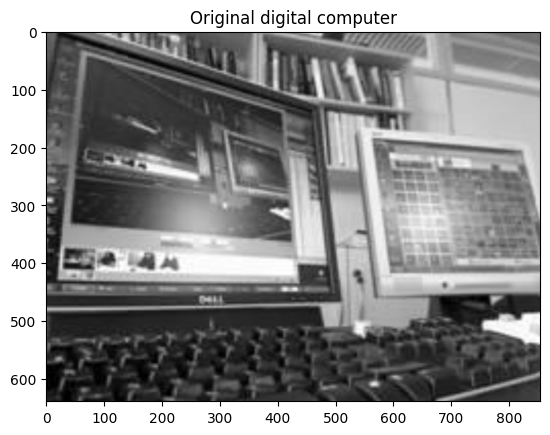

In [6]:
cpt_img_path = "/work/tuan.tt19010226/CV-Radar-HPE/computer.png"
cpt_img = cv2.imread(cpt_img_path)
cpt_gray = cv2.cvtColor(cpt_img, cv2.COLOR_BGR2GRAY)
plt.imshow(cpt_gray, cmap='gray')
plt.title("Original digital computer")
plt.show()

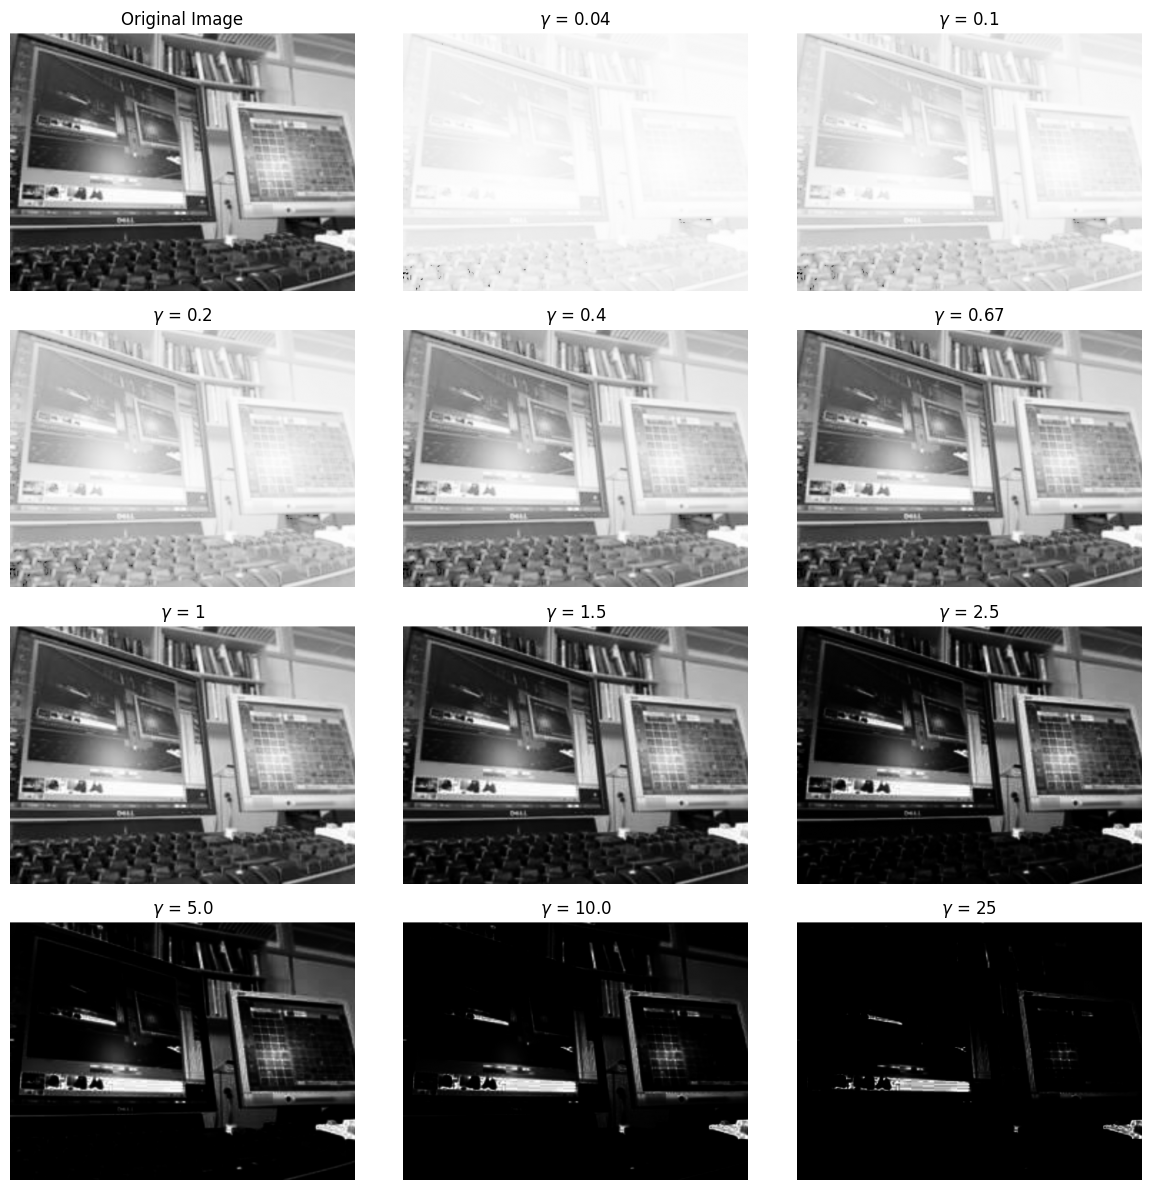

In [7]:
gamma_values = [0.04, 0.1, 0.2, 0.4, 0.67, 1, 1.5, 2.5, 5.0, 10.0, 25]
img_norm = cpt_gray / 255.0
fig, axes = plt.subplots(4, 3, figsize=(12, 12))

axes[0, 0].imshow(cpt_gray, cmap='gray')
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")
for i, gamma in enumerate(gamma_values):
    power_law = np.power(img_norm, gamma)
    power_law = np.uint8(power_law * 255)
    row = (i + 1) // 3
    col = (i + 1) % 3
    axes[row, col].imshow(power_law, cmap='gray')
    axes[row, col].set_title(f"$\\gamma$ = {gamma}")
    axes[row, col].axis("off")
plt.tight_layout()
plt.show()

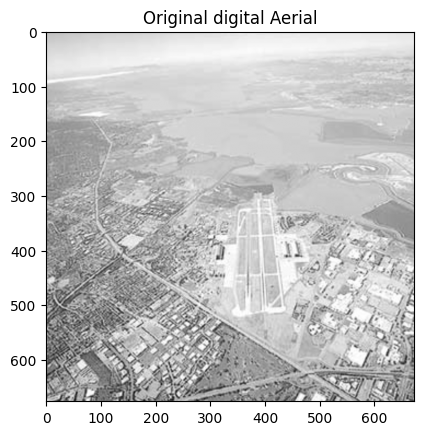

In [8]:
img_2_path = "/work/tuan.tt19010226/CV-Radar-HPE/Aerial.png"
img_2 = cv2.imread(img_2_path)
img_2_gray = cv2.cvtColor(img_2, cv2.COLOR_BGR2GRAY)
plt.imshow(img_2_gray, cmap='gray')
plt.title("Original digital Aerial")
plt.show()

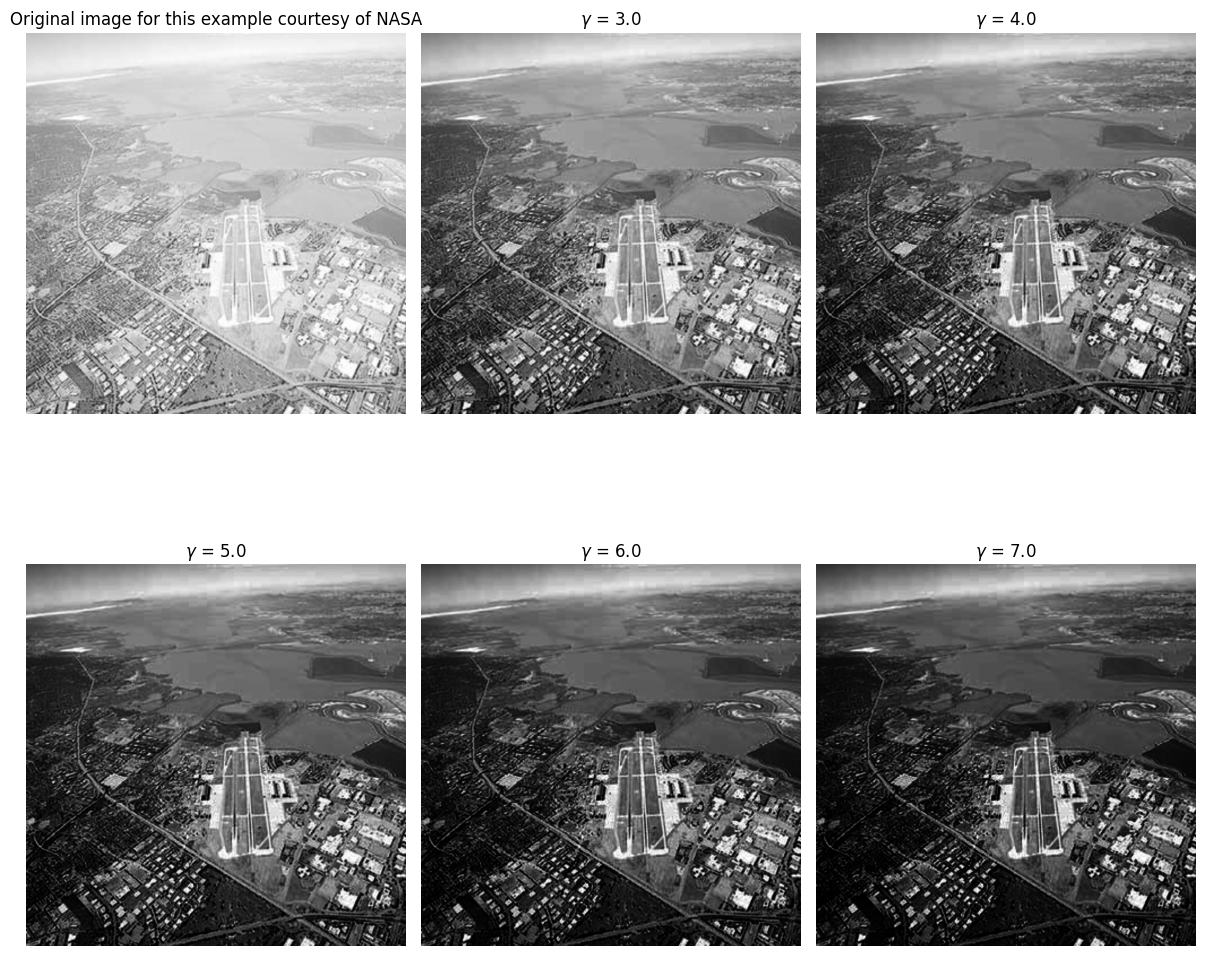

In [9]:
gamma_values = [3.0, 4.0, 5.0, 6.0, 7.0]
img_norm = img_2_gray / 255.0
fig, axes = plt.subplots(2, 3, figsize=(12, 12))

axes[0, 0].imshow(img_2_gray, cmap='gray')
axes[0, 0].set_title("Original image for this example courtesy of NASA")
axes[0, 0].axis("off")
for i, gamma in enumerate(gamma_values):
    power_law = np.power(img_norm, gamma)
    power_law = np.uint8(power_law * 255)
    row = (i + 1) // 3
    col = (i + 1) % 3
    axes[row, col].imshow(power_law, cmap='gray')
    axes[row, col].set_title(f"$\\gamma$ = {gamma}")
    axes[row, col].axis("off")
plt.tight_layout()
plt.show()

### Piecewise-Linear Transformation Functions

#### Intensity-level slicing

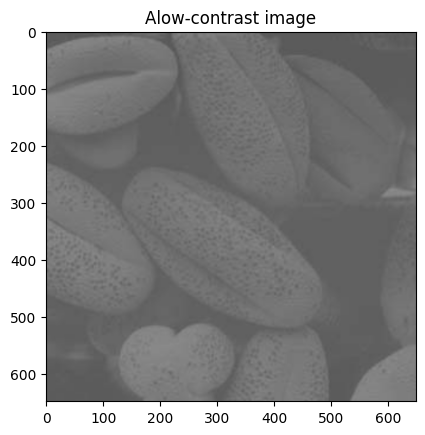

In [10]:
img_3_path = "/work/tuan.tt19010226/CV-Radar-HPE/A low-contrast image.png"
img_3 = cv2.imread(img_3_path)
img_3_gray = cv2.cvtColor(img_3, cv2.COLOR_BGR2GRAY)
plt.imshow(img_3)
plt.title("Alow-contrast image")
plt.show()

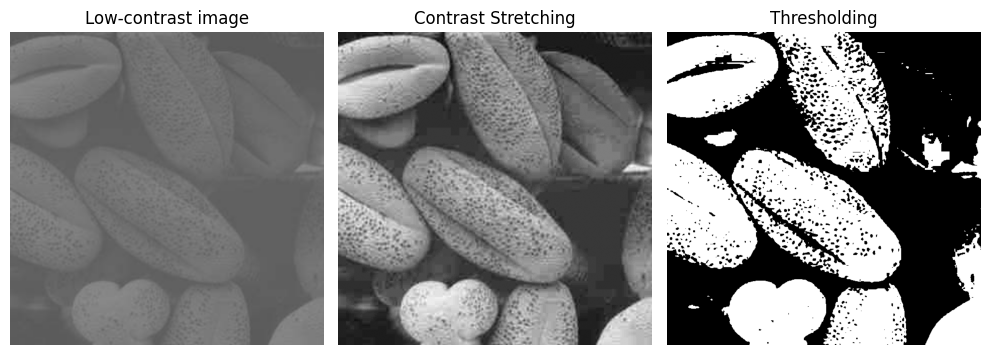

In [11]:
r1, s1 = 70, 0
r2, s2 = 140, 255
stretch = np.zeros_like(img_3_gray)
for y in range(img_3_gray.shape[0]):
    for x in range(img_3_gray.shape[1]):
        r = img_3_gray[y, x]
        if r < r1:
            s = (s1 / r1) * r
        elif r1 <= r < r2:
            s = ((s2 - s1) / (r2 - r1)) * (r - r1) + s1
        else:
            s = ((255 - s2) / (255 - r2)) * (r - r2) + s2
        stretch[y, x] = np.clip(s, 0, 255)

threshold_value = 110
threshold = np.where(img_3_gray > threshold_value, 255, 0).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(10, 10))
ax[0].imshow(img_3, cmap='gray')
ax[0].set_title("Low-contrast image")
ax[0].axis("off")
ax[1].imshow(stretch, cmap='gray')
ax[1].set_title("Contrast Stretching")
ax[1].axis("off")
ax[2].imshow(threshold, cmap='gray')
ax[2].set_title("Thresholding")
ax[2].axis("off")
plt.tight_layout()
plt.show()